In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
excel_file_path=r"C:\Users\100062700\Downloads\Manufacturing data Q4.0.xlsx"
data=pd.read_excel(excel_file_path)

In [3]:
data.head(50)

,Stem Dia(Bottom),Stem Dia(Mid),Stem Dia(Top),Head dia,Seat Height,Undercut Dia,Classification
0,4.983024,4.985908,4.981598,22.992119,1.408910,4.669973,Non-defective
1,4.982693,4.983741,4.980245,22.997031,1.495706,4.677646,defective
2,4.982616,4.983769,4.982393,22.991947,1.390491,4.644406,Non-defective
3,4.982975,4.985024,4.981809,22.997592,1.394742,4.671530,Non-defective
4,4.984229,4.983531,4.982329,22.994082,1.386870,4.679831,defective
5,4.983365,4.985234,4.981623,22.994956,1.444871,4.674549,Non-defective
6,4.982806,4.984991,4.980947,22.993378,1.432407,4.633836,Non-defective
7,4.982644,4.983379,4.981920,22.971894,1.425580,4.634765,Non-defective
8,4.982045,4.983833,4.981302,22.980676,1.411322,4.674081,Non-defective
9,4.984047,4.983193,4.981983,22.954912,1.453124,4.629992,defective


Decision trees

In [4]:
from sklearn.preprocessing import LabelEncoder

# Initialize the Label Encoder
le = LabelEncoder()

# Encode the dependent variable
data['Classification'] = le.fit_transform(data['Classification'])  # Replace 'DependentVariable' with your actual column name


In [5]:
x = data.drop("Classification", axis=1)
y = data["Classification"]

In [6]:
from sklearn.model_selection import train_test_split

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  # 20% test size, 80% train size

# 7nkashe

In [29]:
from sklearn.model_selection import LeaveOneOut

In [30]:
x_train_val, X_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Further split the training set into training and validation sets (80% training, 20% validation)
x_train, X_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.2, random_state=42)


In [31]:
loo = LeaveOneOut()

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
model = DecisionTreeClassifier(random_state=42)

In [28]:
y_val_true = []
y_val_pred = []

# Perform LOOCV on the training set
for train_index, val_index in loo.split(x_train):
    x_train_loo, X_val_loo = x_train[train_index], X_train[val_index]
    y_train_loo, y_val_loo = y_train[train_index], y_train[val_index]
    
    # Fit the model on the training data
    model.fit(x_train_loo, y_train_loo)
    
    # Predict the validation data
    y_val_pred.append(model.predict(X_val_loo)[0])
    y_val_true.append(y_val_loo[0])

# Calculate accuracy on the validation set
val_accuracy = accuracy_score(y_val_true, y_val_pred)
print(f'Validation LOOCV Accuracy: {val_accuracy:.4f}')

# Fit the model on the entire training set
model.fit(x_train, y_train)

# Evaluate the final model on the testing set
y_test_pred = model.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Test Accuracy: {test_accuracy:.4f}')

KeyError: "None of [Int64Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,\n            ...\n            630, 631, 632, 633, 634, 635, 636, 637, 638, 639],\n           dtype='int64', length=639)] are in the [columns]"

In [34]:
# create loocv procedure
cv = LeaveOneOut()
# enumerate splits
y_true, y_pred = list(), list()

#print(cv.get_n_splits(x5))

for train_ix, test_ix in cv.split(x):
    # split data
    x_train , x_test = x.iloc[train_ix] , x.iloc[test_ix]
    
    y_train, y_test = y.iloc[train_ix], y.iloc[test_ix]
    # fit model
    model = DecisionTreeClassifier(random_state=42)
    model.fit(x_train, y_train)
    # evaluate model
    yhat = model.predict(x_test)
    # store
    y_true.append(y_test)
    y_pred.append(yhat)
# calculate accuracy
test_accuracy = accuracy_score(y_test, yhat)
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Accuracy: 1.0000


In [35]:
# Generating the confusion matrix
conf_matrix = confusion_matrix(y_test, yhat)
print('Confusion Matrix:')
print(conf_matrix)

# Generating a classification report
class_report = classification_report(y_test, yhat)
print('Classification Report:')
print(class_report)

Confusion Matrix:
[[1]]
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



C:\Users\100062700\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)
C:\Users\100062700\anaconda3\lib\site-packages\sklearn\metrics\_ranking.py:990: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


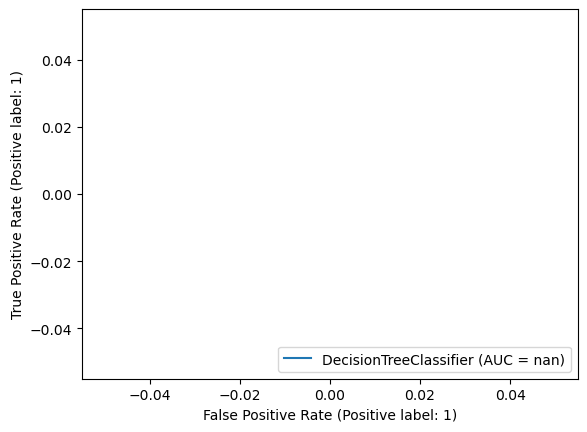

In [36]:
plot_roc_curve(model, x_test, y_test)

# End of LOCV 7nkshe

In [192]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create a decision tree classifier object
clf = DecisionTreeClassifier(random_state=42)

# Train the model
clf.fit(x_train, y_train)

# Predicting the Test set results
y_pred = clf.predict(x_test)

In [193]:
# Calculating the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Generating the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Generating a classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Accuracy: 0.99
Confusion Matrix:
[[119   1]
 [  0  80]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       120
           1       0.99      1.00      0.99        80

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [194]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest classifier object
rf_clf = RandomForestClassifier(random_state=42)

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  # 20% test size, 80% train size

# Train the model on the training data
rf_clf.fit(x_train, y_train)

# Predicting the test set results
y_pred_rf = rf_clf.predict(x_test)

# Calculating the accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {accuracy_rf:.2f}')

# Generating the confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print('Random Forest Confusion Matrix:')
print(conf_matrix_rf)

# Generating a classification report
class_report_rf = classification_report(y_test, y_pred_rf)
print('Random Forest Classification Report:')
print(class_report_rf)


Random Forest Accuracy: 0.99
Random Forest Confusion Matrix:
[[119   1]
 [  0  80]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       120
           1       0.99      1.00      0.99        80

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [195]:
from sklearn.metrics import log_loss, roc_auc_score, recall_score, precision_score, average_precision_score, f1_score, classification_report, accuracy_score, plot_roc_curve, plot_precision_recall_curve, plot_confusion_matrix

C:\Users\100062700\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 1200x1000 with 0 Axes>

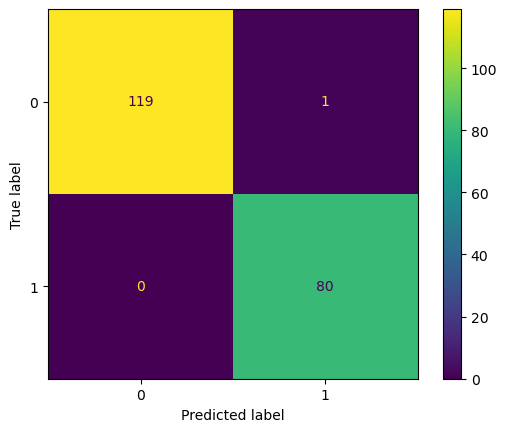

In [196]:
fig = plt.figure(figsize=(12,10))
plot_confusion_matrix(rf_clf, x_test, y_test)
plt.show

C:\Users\100062700\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


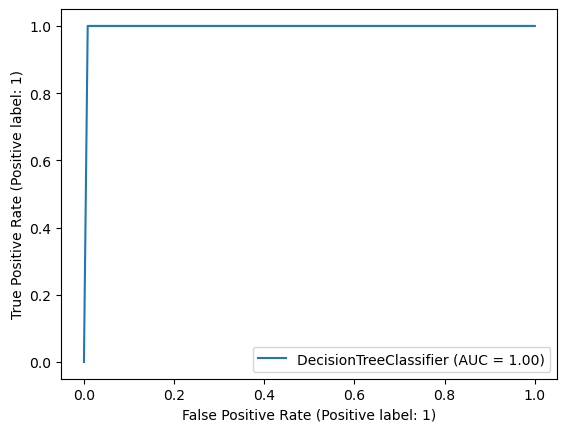

In [197]:
plot_roc_curve(clf, x_test, y_test)

In [40]:
plt.savefig("fathy.png", bbox_inches='tight', dpi=600)

<Figure size 640x480 with 0 Axes>

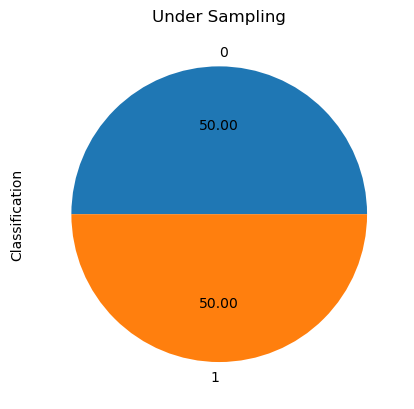

In [42]:
from imblearn.under_sampling import RandomUnderSampler 

rus = RandomUnderSampler(sampling_strategy=1)
x_res, y_res = rus.fit_resample(x, y)

ax = y_res.value_counts().plot.pie(autopct = '%.2f')
_ = ax.set_title("Under Sampling")

In [43]:
X_train, X_test, Y_train, Y_test = train_test_split(x_res, y_res, test_size=0.1, random_state=11)
X_test.shape

(90, 6)

In [131]:
# Train the model on the training data
rf_clf2 = RandomForestClassifier(random_state=42)
rf_clf2.fit(X_train, Y_train)

# Predicting the test set results
y_pred_rf2 = rf_clf.predict(X_test)

# Calculating the accuracy
accuracy_rf = accuracy_score(Y_test, y_pred_rf2)
print(f'Random Forest Accuracy: {accuracy_rf:.2f}')

# Generating the confusion matrix
conf_matrix_rf = confusion_matrix(Y_test, y_pred_rf2)
print('Random Forest Confusion Matrix:')
print(conf_matrix_rf)

# Generating a classification report
class_report_rf = classification_report(Y_test, y_pred_rf2)
print('Random Forest Classification Report:')
print(class_report_rf)

Random Forest Accuracy: 1.00
Random Forest Confusion Matrix:
[[41  0]
 [ 0 49]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        49

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



In [132]:
print(y_pred_rf2)
print(Y_test.array)
print(y_pred_rf2-Y_test.array)
#print(sum(y_pred_rf2-Y_test.array)**2))

[0 1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 0 1 1 0 0 1 1 1 1 0 0 0 1 0 0 1 1
 0 0 1 0 0 0 1 1 1 0 0 1 1 0 0 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 0
 0 1 0 0 0 1 1 1 1 0 1 1 0 0 0 0]
<PandasArray>
[0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1,
 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0,
 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0]
Length: 90, dtype: int32
<PandasArray>
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 90, dtype: int32


In [133]:
y_pred_rf2.shape

(90,)

In [49]:
Y_test.shape

(90,)

In [134]:
# Importing necessary libraries
from sklearn.svm import SVC

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  # 20% test size, 80% train size

# Creating and training the SVM model
svm_model = SVC(kernel='linear', random_state=42)  # Using a linear kernel; change as needed
svm_model.fit(x_train, y_train)

# Making predictions on the test set
y_pred = svm_model.predict(x_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Output the results
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)


Accuracy: 0.60
Confusion Matrix:
[[120   0]
 [ 80   0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75       120
           1       0.00      0.00      0.00        80

    accuracy                           0.60       200
   macro avg       0.30      0.50      0.37       200
weighted avg       0.36      0.60      0.45       200



C:\Users\100062700\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\100062700\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\100062700\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


C:\Users\100062700\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


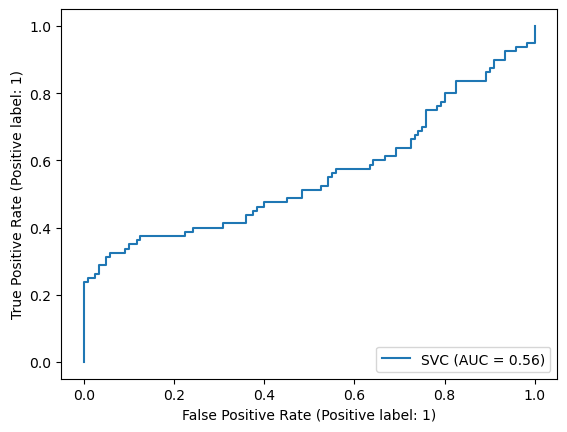

In [135]:
plot_roc_curve(svm_model, x_test, y_test)

In [136]:
# Importing necessary libraries
from sklearn.ensemble import GradientBoostingClassifier

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  # 20% test size, 80% train size

# Creating and training the Gradient Boosting classifier
gbm_model = GradientBoostingClassifier(random_state=42)
gbm_model.fit(x_train, y_train)

# Making predictions on the test set
y_pred = gbm_model.predict(x_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Output the results
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)


Accuracy: 0.99
Confusion Matrix:
[[119   1]
 [  0  80]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       120
           1       0.99      1.00      0.99        80

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



C:\Users\100062700\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


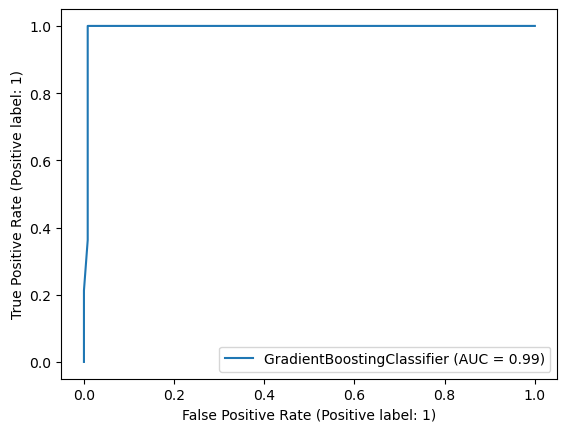

In [137]:
plot_roc_curve(gbm_model, x_test, y_test)

In [138]:
from sklearn.linear_model import LogisticRegression

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  # 20% test size, 80% train size

# Creating and training the Logistic Regression model
logreg_model = LogisticRegression(random_state=42, max_iter=1000)
logreg_model.fit(x_train, y_train)

# Making predictions on the test set
y_pred = logreg_model.predict(x_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Output the results
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.62
Confusion Matrix:
[[120   0]
 [ 75   5]]
Classification Report:
              precision    recall  f1-score   support

           0       0.62      1.00      0.76       120
           1       1.00      0.06      0.12        80

    accuracy                           0.62       200
   macro avg       0.81      0.53      0.44       200
weighted avg       0.77      0.62      0.50       200



C:\Users\100062700\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


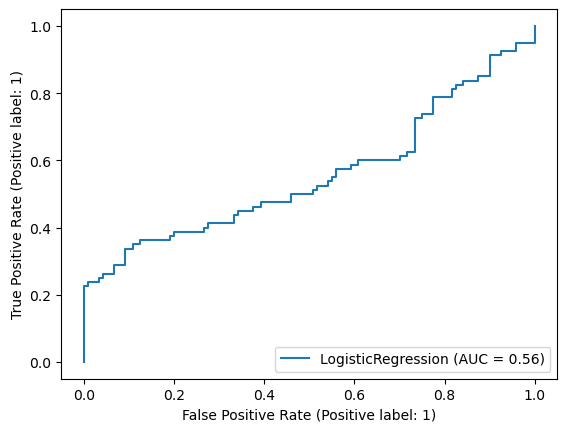

In [139]:
plot_roc_curve(logreg_model, x_test, y_test)

In [140]:
# Importing necessary libraries
from sklearn.naive_bayes import GaussianNB

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  # 20% test size, 80% train size

# Creating and training the Gaussian Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(x_train, y_train)

# Making predictions on the test set
y_pred = nb_model.predict(x_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Output the results
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.82
Confusion Matrix:
[[107  13]
 [ 23  57]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       120
           1       0.81      0.71      0.76        80

    accuracy                           0.82       200
   macro avg       0.82      0.80      0.81       200
weighted avg       0.82      0.82      0.82       200



C:\Users\100062700\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


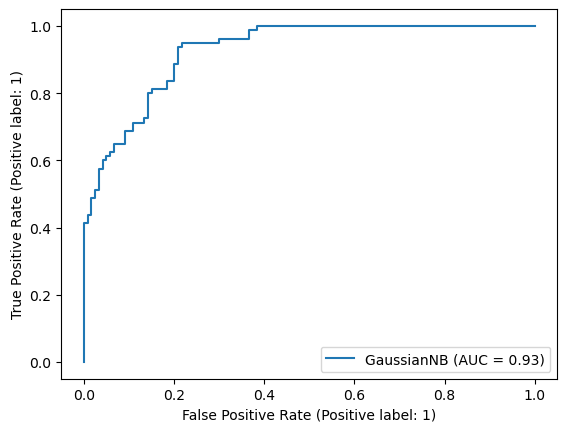

In [141]:
plot_roc_curve(nb_model, x_test, y_test)

C:\Users\100062700\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)
C:\Users\100062700\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)
C:\Users\100062700\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and w

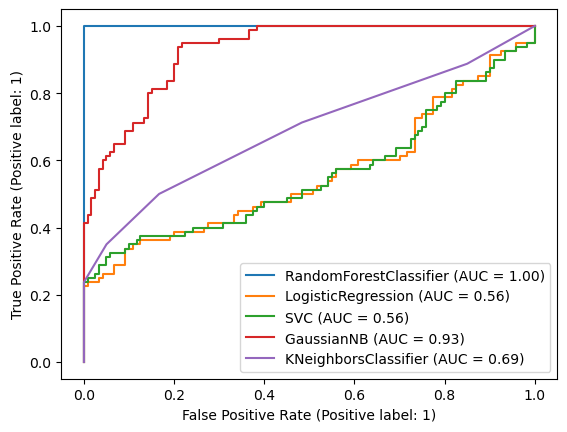

In [142]:
rf = plot_roc_curve(rf_clf, x_test, y_test)
logreg = plot_roc_curve(logreg_model, x_test, y_test, ax=rf.ax_)
svm = plot_roc_curve(svm_model, x_test, y_test, ax=rf.ax_)
nb = plot_roc_curve(nb_model, x_test, y_test, ax=rf.ax_)
knn = plot_roc_curve(knn_model, x_test, y_test, ax=rf.ax_)
#ann = plot_roc_curve(model, x_test, y_test, ax=rf.ax_)

In [109]:
# Importing necessary libraries
from sklearn.neighbors import KNeighborsClassifier

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  # 20% test size, 80% train size

# Creating and training the K-Nearest Neighbors model
# Starting with n_neighbors=5, which is the default, adjust based on performance and dataset size
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)

# Making predictions on the test set
y_pred = knn_model.predict(x_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Output the results
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.70
Confusion Matrix:
[[100  20]
 [ 40  40]]
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.83      0.77       120
           1       0.67      0.50      0.57        80

    accuracy                           0.70       200
   macro avg       0.69      0.67      0.67       200
weighted avg       0.70      0.70      0.69       200



C:\Users\100062700\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


# ANN

7/7 [==============================] - 0s 4ms/step - loss: 0.3970 - accuracy: 0.8100
Test Loss: 0.3970
Test Accuracy: 0.81


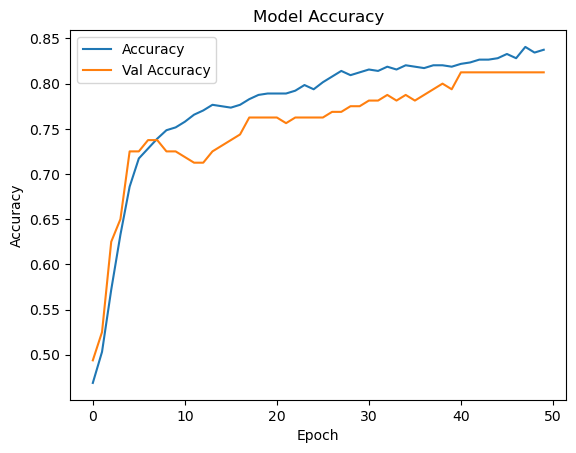

In [198]:
# Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import BinaryAccuracy

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  # 20% test size, 80% train size

# Data normalization
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Creating the ANN model
model = Sequential([
    Dense(10, activation='relu', input_shape=(x_train.shape[1],)),  # Adjust number of neurons and add more layers as needed
    Dense(1, activation='sigmoid')
])

# Compiling the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[BinaryAccuracy(name='accuracy')])

# Training the model
history = model.fit(x_train, y_train, epochs=50, batch_size=10, validation_split=0.2, verbose=0)

# Evaluating the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.2f}')

# Optionally, plot training history for loss and accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [199]:
np.round(model.predict(x_train),0) # 1 and 0 (survival or not)
#Y # 1 and 0 (survival or not)

# so we need to round to a whole number (0 or 1),
# or the confusion matrix won't work!
preds = np.round(model.predict(x_test),0)

# confusion matrix
print(confusion_matrix(y_test, preds))

7/7 [==============================] - 0s 3ms/step
[[103  17]
 [ 21  59]]


In [200]:

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       120
           1       0.78      0.74      0.76        80

    accuracy                           0.81       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.81      0.81      0.81       200



In [201]:
preds=preds.flatten()

In [202]:
#tests_predictions = model.predict(x_test, steps=1).flatten()
tests_results = pd.DataFrame(data={'Test Predictions':preds, 'Actual test values':y_test})
tests_results

,Test Predictions,Actual test values
521,1.0,0
737,1.0,0
740,0.0,0
660,1.0,1
411,0.0,0
...,...,...
408,0.0,0
332,0.0,0
208,0.0,0
613,0.0,0


In [182]:
fig = plt.figure(figsize=(12,10))
plot_confusion_matrix(model, x_test, y_test)
plt.show

C:\Users\100062700\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


ValueError: plot_confusion_matrix only supports classifiers

<Figure size 1200x1000 with 0 Axes>

# LSTM

In [7]:
from tensorflow.keras.layers import LSTM, SimpleRNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import BinaryAccuracy
from tensorflow.keras.layers import *
from keras.callbacks import EarlyStopping

In [8]:
model_lstm=Sequential()
model_lstm.add(InputLayer((43, 1)))
model_lstm.add(LSTM(200))
model_lstm.add(Dense(128, 'relu'))
model_lstm.add(Dense(64, 'relu'))
model_lstm.add(Dense(1, 'linear'))

model_lstm.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 200)               161600    
                                                                 
 dense (Dense)               (None, 128)               25728     
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 195,649
Trainable params: 195,649
Non-trainable params: 0
_________________________________________________________________


In [9]:
#model = Sequential([
#    InputLayer(input_shape=(x_train.shape[1],)),
#    LSTM(200)
#    Dense(128, activation='relu'),
#    Dense(64, activation='relu'),
#    Dense(10, activation='relu'),  # Adjust number of neurons and add more layers as needed
#    Dense(1, activation='sigmoid')
#])

model=Sequential()
model.add(InputLayer((6, 1)))
model.add(LSTM(200))
model.add(Dense(128, 'relu'))
model.add(Dense(64, 'relu'))
model.add(Dense(1, 'sigmoid'))

model.summary()

# Compiling the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[BinaryAccuracy(name='accuracy')])

es = EarlyStopping(monitor='val_accuracy', 
                                   mode='max', # don't minimize the accuracy!
                                   patience=10,
                                   restore_best_weights=True)

# Training the model
history = model.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0)

# Evaluating the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.2f}')

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 200)               161600    
                                                                 
 dense_3 (Dense)             (None, 128)               25728     
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 
Total params: 195,649
Trainable params: 195,649
Non-trainable params: 0
_________________________________________________________________
7/7 [==============================] - 1s 14ms/step - loss: 0.6822 - accuracy: 0.6000
Test Loss: 0.6822
Test Accuracy: 0.60


7/7 [==============================] - 0s 6ms/step - loss: 0.6822 - accuracy: 0.6000
Test Loss: 0.6822
Test Accuracy: 0.60


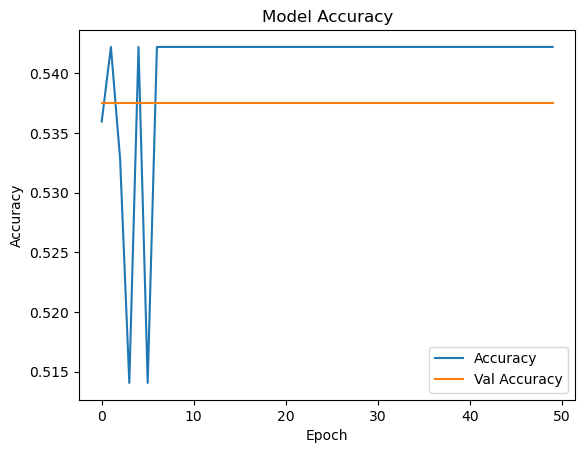

In [10]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.2f}')

# Optionally, plot training history for loss and accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import log_loss, roc_auc_score, recall_score, precision_score, average_precision_score, f1_score, classification_report, accuracy_score, plot_roc_curve, plot_precision_recall_curve, plot_confusion_matrix
np.round(model.predict(x_train),0) # 1 and 0 (survival or not)
#Y # 1 and 0 (survival or not)

# so we need to round to a whole number (0 or 1),
# or the confusion matrix won't work!
preds = np.round(model.predict(x_test),0)

# confusion matrix
print(confusion_matrix(y_test, preds))

7/7 [==============================] - 0s 4ms/step
[[120   0]
 [ 80   0]]


In [14]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.60      1.00      0.75       120
           1       0.00      0.00      0.00        80

    accuracy                           0.60       200
   macro avg       0.30      0.50      0.37       200
weighted avg       0.36      0.60      0.45       200



C:\Users\100062700\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\100062700\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\100062700\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [15]:
preds=preds.flatten()

In [16]:
#tests_predictions = model.predict(x_test, steps=1).flatten()
tests_results = pd.DataFrame(data={'Test Predictions':preds, 'Actual test values':y_test})
tests_results

,Test Predictions,Actual test values
521,0.0,0
737,0.0,0
740,0.0,0
660,0.0,1
411,0.0,0
...,...,...
408,0.0,0
332,0.0,0
208,0.0,0
613,0.0,0


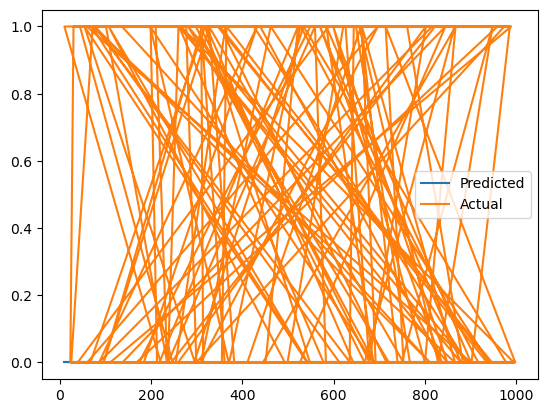

In [17]:
plt.plot(tests_results['Test Predictions'], label='Predicted')
plt.plot(tests_results['Actual test values'], label='Actual')
plt.legend()

In [74]:
accuracy = accuracy_score(y_test, tests_predictions)
conf_matrix = confusion_matrix(y_test, tests_predictions)
class_report = classification_report(y_test, tests_predictions)

# Output the results
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

ValueError: Classification metrics can't handle a mix of binary and continuous targets

# CNN

In [159]:
model=Sequential()
model.add(InputLayer((6, 1)))
model.add(Conv1D(64, kernel_size=2))
model.add(Flatten())
model.add(Dense(128, 'relu'))
model.add(Dense(64, 'relu'))
model.add(Dense(1, 'sigmoid'))

model.summary()

# Compiling the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[BinaryAccuracy(name='accuracy')])

# Training the model
history = model.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0)

# Evaluating the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.2f}')

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_1 (Conv1D)           (None, 5, 64)             192       
                                                                 
 flatten_1 (Flatten)         (None, 320)               0         
                                                                 
 dense_30 (Dense)            (None, 128)               41088     
                                                                 
 dense_31 (Dense)            (None, 64)                8256      
                                                                 
 dense_32 (Dense)            (None, 1)                 65        
                                                                 
Total params: 49,601
Trainable params: 49,601
Non-trainable params: 0
_________________________________________________________________
7/7 [==============================] - 1s 5ms/ste

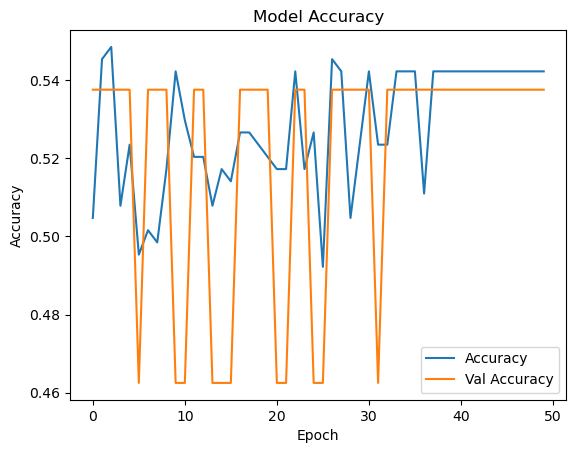

In [160]:


# Optionally, plot training history for loss and accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [161]:
np.round(model.predict(x_train),0) # 1 and 0 (survival or not)
#Y # 1 and 0 (survival or not)

# so we need to round to a whole number (0 or 1),
# or the confusion matrix won't work!
preds = np.round(model.predict(x_test),0)

# confusion matrix
print(confusion_matrix(y_test, preds))

7/7 [==============================] - 0s 5ms/step
[[120   0]
 [ 80   0]]


In [162]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.60      1.00      0.75       120
           1       0.00      0.00      0.00        80

    accuracy                           0.60       200
   macro avg       0.30      0.50      0.37       200
weighted avg       0.36      0.60      0.45       200



C:\Users\100062700\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\100062700\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\100062700\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [166]:
preds=preds.flatten()

In [167]:
#tests_predictions = model.predict(x_test, steps=1).flatten()
tests_results = pd.DataFrame(data={'Test Predictions':preds, 'Actual test values':y_test})
tests_results

,Test Predictions,Actual test values
521,0.0,0
737,0.0,0
740,0.0,0
660,0.0,1
411,0.0,0
...,...,...
408,0.0,0
332,0.0,0
208,0.0,0
613,0.0,0


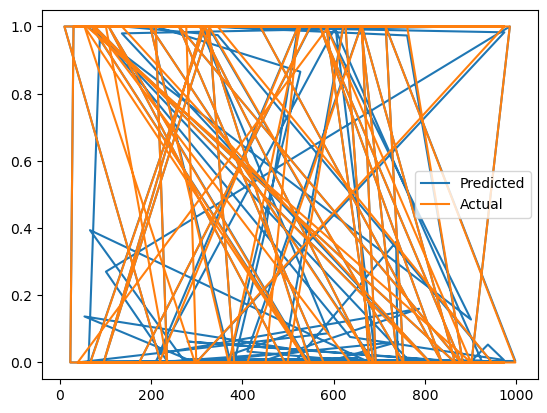

In [81]:
plt.plot(tests_results['Test Predictions'][:100], label='Predicted')
plt.plot(tests_results['Actual test values'][:100], label='Actual')
plt.legend()